In [88]:
# --- IMPORT STATEMENTS ---

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from reproject import reproject_interp
import healpy as hp

In [89]:
# --- GLOBAL VARIABLES ---

SAVE_FIGS = False

LINUX_DIRECTORY = "/home/aimee/mphys" # Aimee
FIGURE_SAVEDIR = "figures" # Aimee
MAPS_DIR = f'{LINUX_DIRECTORY}/data/3D_wcs_maps' # Aimee
MAPS_SAVEDIR = f'{LINUX_DIRECTORY}/data/maps'

EFFELSBERG_MAPS = { # name : [file name, frequency / Hz]
    "Effelsberg 2.73 GHz" : ['Effelsberg_2.7272GHz_raw.fits'] # raw from website - 3D WCS (code can't handle it)
    # "Effelsberg 2.73 GHz" : ["EFFELSBERG-2.7272727272727275GHz-5.0amin.fits"] # TJ Rennie's pre-processed map (not ideal, but WCS works)
}

NOBEYAMA_MAPS = { # name : [file name, frequency / Hz]
   "Nobeyama 10 GHz" : ["Nobeyama_10.0GHz_raw.fits"] # raw from website - 3D WCS (code can't handle it)
    # "Nobeyama 10 GHz" : ["NOBEYAMA-10.0GHz-5.0amin.fits"] # TJ Rennie's pre-processed map (not ideal, but WCS works)
}

PARKES_MAPS = { # name : [file name, frequency / Hz]
    "Parkes 5 GHz" : ["Parkes_5.0GHz_raw.fits"] # raw from website - 3D WCS (code can't handle it)
    # "Parkes 5 GHz" : ["PARKES-5.0GHz-5.0amin.fits"] # CORRUPTED
}

In [90]:
# --- FUNCTION DEFINTIONS ---

def get_map(path):
    
    print(f"Getting data from {path}")
    fits_file = fits.open(path)

    data = fits_file[0].data
    header = fits_file[0].header
    wcs = WCS(header)
        
    return data, header, wcs

In [91]:
def plot_fits(fits_data, projection, x_coords=[], y_coords=[], title='Title', save_figs=SAVE_FIGS):
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting
    
    vmin = 0 #np.nanpercentile(fits_data, 0.)
    vmax = np.nanpercentile(fits_data, 99.5)

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin=vmin , vmax=vmax)
    
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        ax.plot(x_coords, y_coords, 'rx', markersize=3)
    
    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_b$ [mK]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if save_figs:
        plt.savefig(f"{LINUX_DIRECTORY}/{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()

In [92]:
def make_2d(data, header, wcs):

    # print(f'\nOLD WCS/HEADER:')
    # print(wcs)
    # print(header)

    data = data[0, :, :]

    new_wcs = WCS(header).celestial # Use only celestial part of WCS (if it's a multi-dimensional WCS)
    new_wcs.wcs.ctype = ['GLON-CAR', 'GLAT-CAR'] 

    new_wcs.wcs.crpix[0] = wcs.wcs.crpix[0]
    new_wcs.wcs.crpix[1] = wcs.wcs.crpix[1]
    new_wcs.wcs.cdelt[0] = wcs.wcs.cdelt[0]
    new_wcs.wcs.cdelt[1] = wcs.wcs.cdelt[1]
    new_wcs.wcs.crval[0] = wcs.wcs.crval[0]
    new_wcs.wcs.crval[1] = wcs.wcs.crval[1]

    new_header = new_wcs.to_header()

    # print('\nNEW WCS/HEADER:')
    # print(new_wcs)
    # print(header_new)

    return data, new_header, new_wcs

In [93]:
def save_fits(data, header, savepath):
    hdu = fits.PrimaryHDU(data=data, header=header)
    # hdu.header['BUNIT'] = 'Jy/sr'
    hdu.header['NAXIS1'] = data.shape[1]
    hdu.header['NAXIS2'] = data.shape[0]
    hdu.writeto(savepath, overwrite=True)
    print(f'Map saved to {savepath}')

In [94]:
# can use reproject for oversampling - fluxes will not be correct but once rebin and average in maps_processing.ipynb (T-T plots etc), will be correct

def reproject_data(data, wcs, shape_out, pixel_scale_deg):
    
    # Get the center of the original image (mosaic_wcs)
    center_pix = np.array(data.shape) / 2
    center_lon, center_lat = wcs.pixel_to_world_values(center_pix[1], center_pix[0]) 

    # Determine angular size of the original image (in degrees)
    orig_scales = proj_plane_pixel_scales(wcs)  # degrees/pixel in x and y
    size_deg_x = orig_scales[0] * data.shape[1]
    size_deg_y = orig_scales[1] * data.shape[0]

    # Compute new shape in pixels for the same area with 1 arcmin/pixel
    new_shape_x = int(np.ceil(size_deg_x / pixel_scale_deg))
    new_shape_y = int(np.ceil(size_deg_y / pixel_scale_deg))
    new_shape = (new_shape_y, new_shape_x)

    # Create a new WCS
    new_wcs = WCS(naxis=2)
    new_wcs.wcs.crval = [center_lon, center_lat]              # center of the image in degrees
    new_wcs.wcs.crpix = [new_shape[1] / 2, new_shape[0] / 2]  # center pixel for new shape
    new_wcs.wcs.ctype = list(wcs.wcs.ctype)           # keep original projection
    new_wcs.wcs.cdelt = np.array([-pixel_scale_deg, pixel_scale_deg])  # pixel scale in degrees

    # Reproject the mosaic to the new WCS
    data_reprojected, footprint = reproject_interp(
        (data, wcs),
        new_wcs,
        shape_out=new_shape
    )

    # Convert the WCS to a FITS header
    new_header = new_wcs.to_header()

    return data_reprojected, new_wcs, new_header


Getting data from /home/aimee/mphys/data/3D_wcs_maps/Nobeyama_10.0GHz_raw.fits


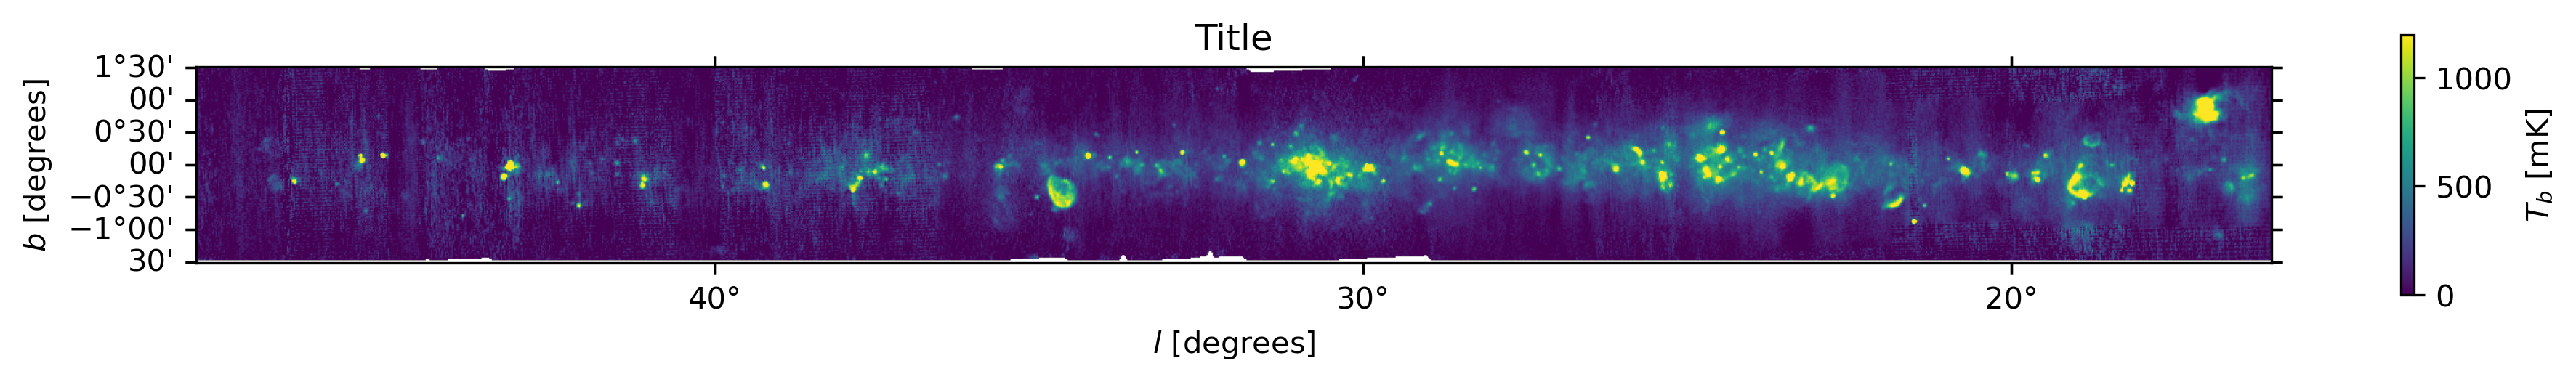

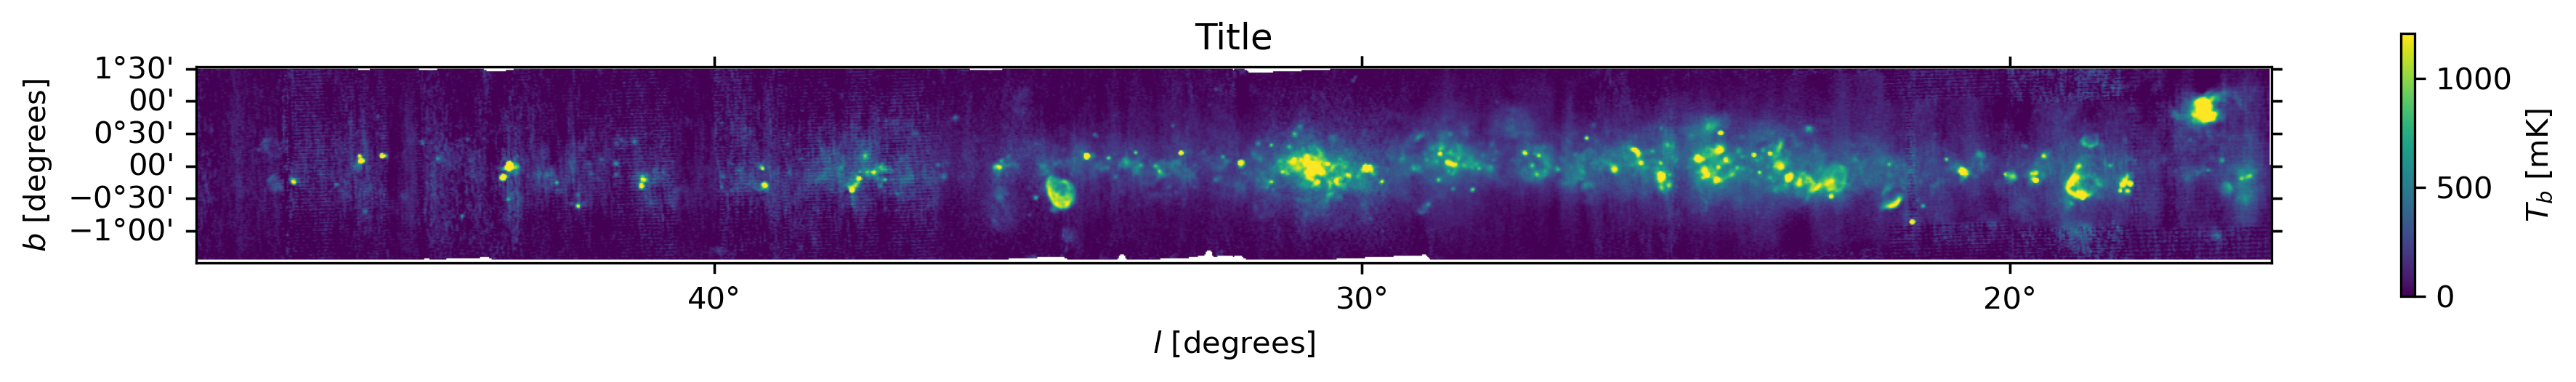

Map saved to /home/aimee/mphys/data/maps/Nobeyama_10.0GHz_raw_1arcmin.fits


In [95]:
# --- MAIN CODE --- 

# map_name = "Parkes_5.0GHz_raw.fits"
# map_name = 'Effelsberg_2.7272GHz_raw.fits'
map_name = "Nobeyama_10.0GHz_raw.fits"

map_path = f'{MAPS_DIR}/{map_name}'
data, header, wcs = get_map(map_path)
data, header, wcs = make_2d(data, header, wcs)
plot_fits(data, wcs)
# save_fits(data, header, savepath= f'{MAPS_SAVEDIR}/{map_name.replace(".fits", "")}_2d.fits')

target_step = 1/60 # 1 arcmin
step = wcs.wcs.cdelt[1]
factor = step / target_step
shape = data.shape
shape_out = (shape[0]*factor, shape[1]*factor)
# print(factor)
# print(shape)
# print(shape_out)
data_reprojected, new_wcs, new_header = reproject_data(data, wcs, shape_out, step)

plot_fits(data_reprojected, new_wcs)

save_fits(data, header, savepath= f'{MAPS_SAVEDIR}/{map_name.replace(".fits", "")}_1arcmin.fits')
